In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('adult.csv')

In [3]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.head

<bound method NDFrame.head of        age     workclass  fnlwgt     education  educational-num  \
0       25       Private  226802          11th                7   
1       38       Private   89814       HS-grad                9   
2       28     Local-gov  336951    Assoc-acdm               12   
3       44       Private  160323  Some-college               10   
4       18             ?  103497  Some-college               10   
...    ...           ...     ...           ...              ...   
48837   27       Private  257302    Assoc-acdm               12   
48838   40       Private  154374       HS-grad                9   
48839   58       Private  151910       HS-grad                9   
48840   22       Private  201490       HS-grad                9   
48841   52  Self-emp-inc  287927       HS-grad                9   

           marital-status         occupation relationship   race  gender  \
0           Never-married  Machine-op-inspct    Own-child  Black    Male   
1      Marrie

In [5]:
#gives all columns in the dataset
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [6]:
#gives the size of the dataset
df.size

732630

In [7]:
#gives the shape of the dataset
df.shape

(48842, 15)

In [8]:
#
df.isin(['?']).sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [9]:
#replacing the '?' with NaN
df["workclass"]=df["workclass"].replace('?',np.NaN)
df["occupation"]=df["occupation"].replace('?',np.NaN)
df["native-country"]=df["native-country"].replace('?',np.NaN)
df["workclass"]

0             Private
1             Private
2           Local-gov
3             Private
4                 NaN
             ...     
48837         Private
48838         Private
48839         Private
48840         Private
48841    Self-emp-inc
Name: workclass, Length: 48842, dtype: object

In [10]:
#dropping the NaN values
df.dropna(how='any',inplace=True)
print(df.shape)
#checking for duplicates and giving the count
print(df.duplicated().sum())

(45222, 15)
47


In [11]:
#dropping the duplicates
df=df.drop_duplicates()
#checking for duplicates and giving the count
print(df.duplicated().sum())

0


In [12]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [13]:
#dropping the columns which are not required
df.drop(['fnlwgt','educational-num','marital-status','relationship','race'],axis=1,inplace=True)
df.columns

/var/folders/sc/pyr082j14t36c2ncdpf_lnzw0000gn/T/ipykernel_20373/3386875405.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['fnlwgt','educational-num','marital-status','relationship','race'],axis=1,inplace=True)


Index(['age', 'workclass', 'education', 'occupation', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [14]:
#selecting a subset of the data
x=df.iloc[:,df.columns!='income']
y=df.iloc[:,df.columns=='income'] # or y=df[:,'income']

In [15]:
x
y

,income
0,<=50K
1,<=50K
2,>50K
3,>50K
5,<=50K
...,...
48837,<=50K
48838,>50K
48839,<=50K
48840,<=50K


In [16]:
from sklearn.preprocessing import LabelEncoder
y=LabelEncoder().fit_transform(y)
y=pd.DataFrame(y)
y

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
#tak
numerical_features=x.select_dtypes('number')
catagorical_features=x.select_dtypes('object')
numerical_features

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40
1,38,0,0,50
2,28,0,0,40
3,44,7688,0,40
5,34,0,0,30
...,...,...,...,...
48837,27,0,0,38
48838,40,0,0,40
48839,58,0,0,40
48840,22,0,0,20


In [ ]:
catagorical_features

,workclass,education,occupation,gender,native-country
0,Private,11th,Machine-op-inspct,Male,United-States
1,Private,HS-grad,Farming-fishing,Male,United-States
2,Local-gov,Assoc-acdm,Protective-serv,Male,United-States
3,Private,Some-college,Machine-op-inspct,Male,United-States
5,Private,10th,Other-service,Male,United-States
...,...,...,...,...,...
48837,Private,Assoc-acdm,Tech-support,Female,United-States
48838,Private,HS-grad,Machine-op-inspct,Male,United-States
48839,Private,HS-grad,Adm-clerical,Female,United-States
48840,Private,HS-grad,Adm-clerical,Male,United-States


In [ ]:
converted_catagorical_features=pd.get_dummies(catagorical_features)
converted_catagorical_features.shape

(45175, 80)

In [ ]:
all_features=[converted_catagorical_features,numerical_features]
newX=pd.concat(all_features,axis=1,join='inner')
newX.shape

(45175, 84)

In [ ]:
newX.head()

,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,...,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,age,capital-gain,capital-loss,hours-per-week
0,False,False,True,False,False,False,False,False,True,False,...,False,False,False,True,False,False,25,0,0,40
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,38,0,0,50
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,28,0,0,40
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,44,7688,0,40
5,False,False,True,False,False,False,False,True,False,False,...,False,False,False,True,False,False,34,0,0,30


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(newX,y,test_size=0.33,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(max_depth=5)
clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
y_test.shape

(14908, 1)

In [ ]:
y_pred.shape

(14908,)

In [ ]:
prediction_df=pd.DataFrame()
prediction_df['predicted_salary_class']=y_pred
prediction_df['actual_salary_class']=y_test[0].values
prediction_df

,predicted_salary_class,actual_salary_class
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
14903,0,0
14904,0,1
14905,0,0
14906,0,0


In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.8196941239602897


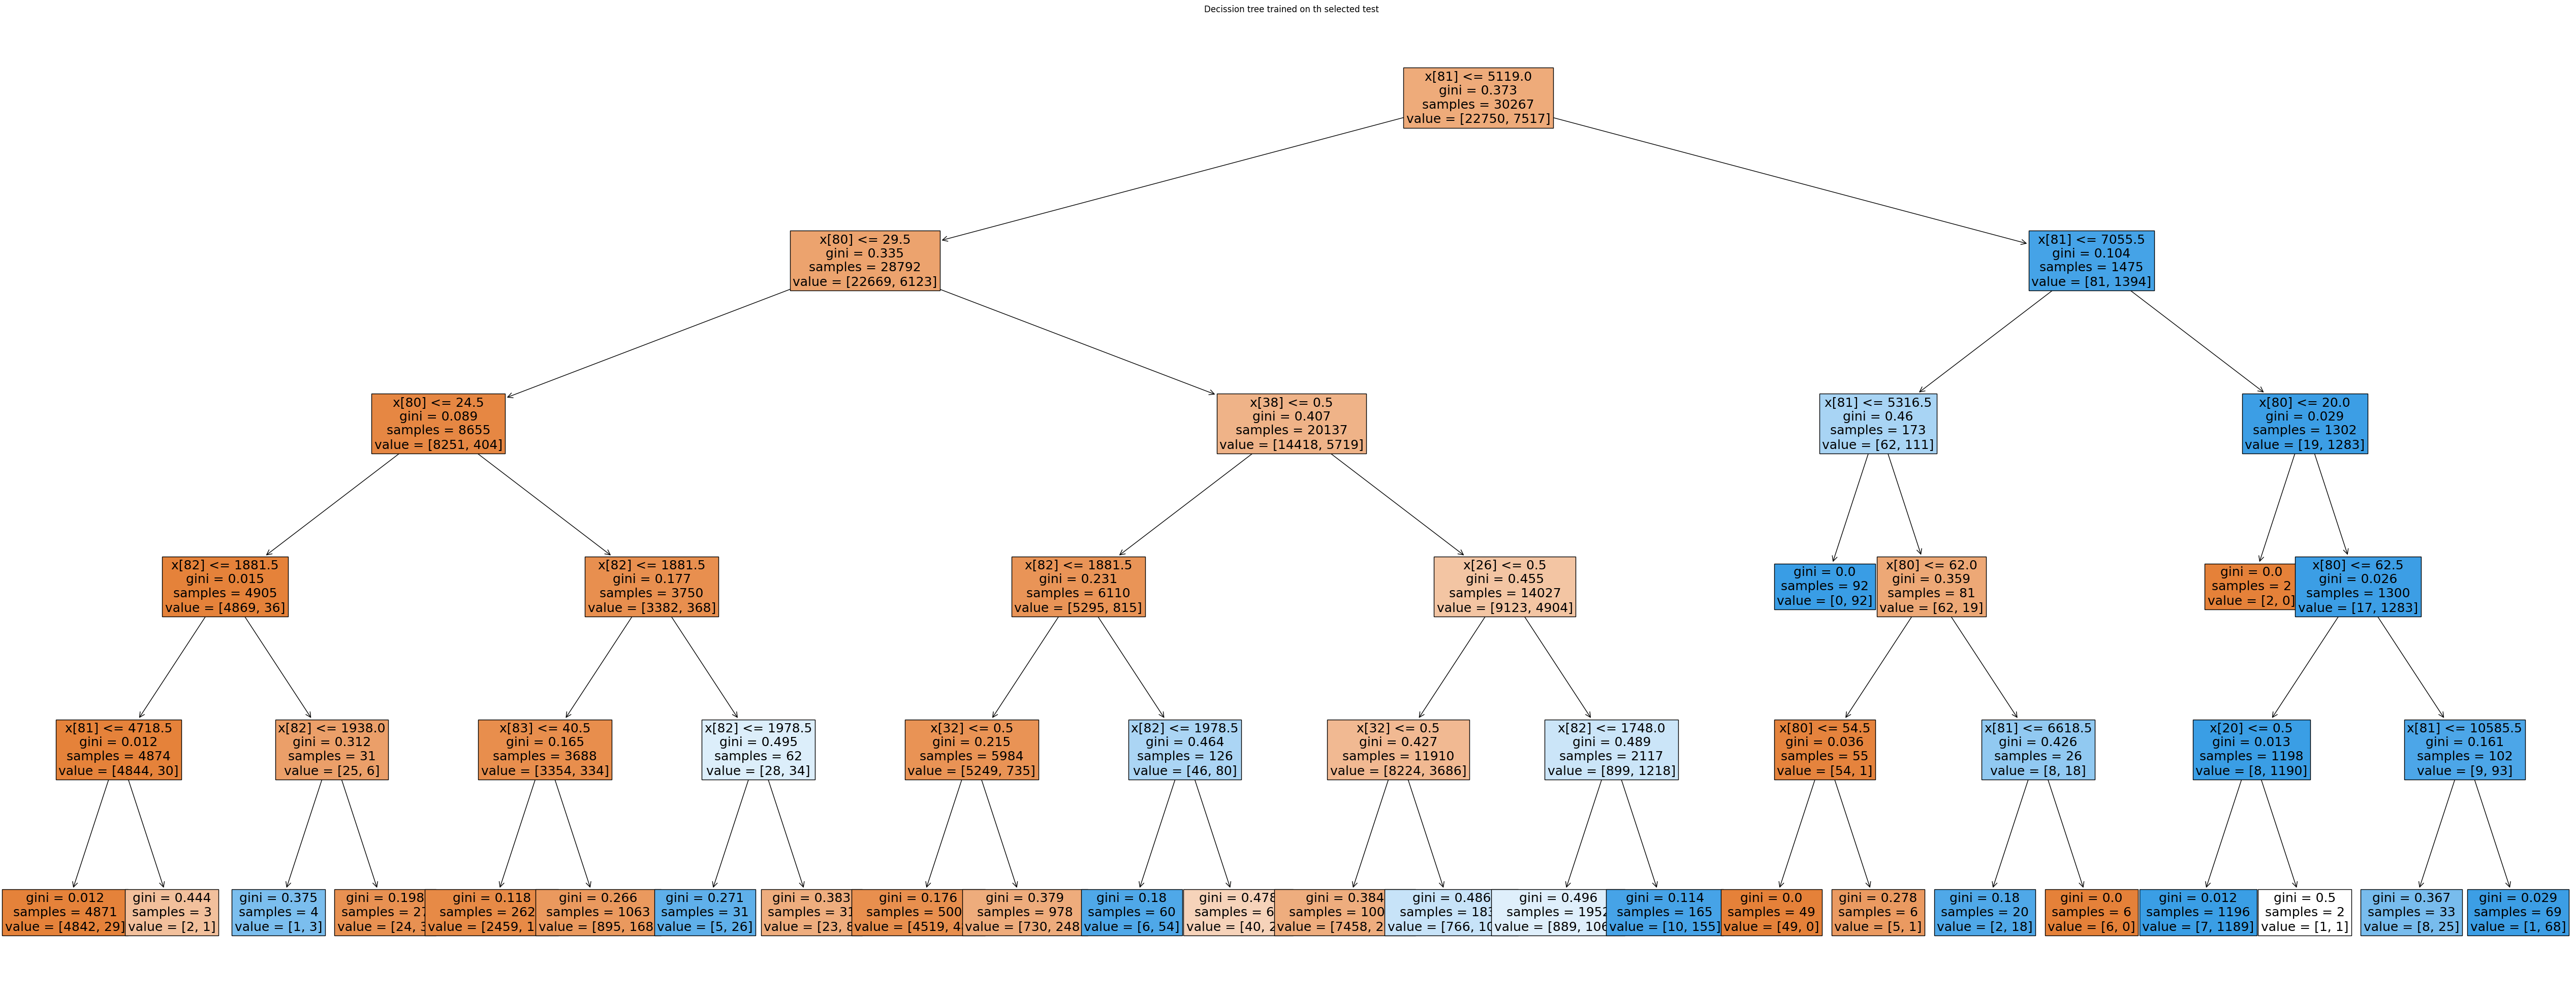

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(65,25))
plot_tree(clf,fontsize=18,filled=True)
plt.title("Decission tree trained on th selected test")
plt.show()